# RUNOFF event generation (NextGen-friendly)
## Flash flood events → hydrofabric catchment outlet → radar coverage

**Inputs** (paths are set in the next cell):
1. **NextGen hydrofabric GeoPackage** with the `network`, `divides`, `flowpaths` and `nexus` layers. Without a `nexus` layer, the downstream end of the storm's flowpath is used as the outlet instead.
2. **MRMS radar coverage raster** (percent).
3. *(Optional)* **GAGES-II CSV** (`STAID`, `LAT_GAGE`, `LNG_GAGE`, optional `DRAIN_SQKM`). Only needed when `MATCH_GAGES = True`.

## 0. Settings

In [1]:
from pathlib import Path

# Years to process
START_YEAR = 2021
END_YEAR = 2025

# Event clustering 
TIME_WINDOW_HOURS = 24            # max gap between report BEGIN times for a link
LONG_EVENT_THRESHOLD_HOURS = 48   # QA flag only, events are not capped
BUFFER_KM = 0.0                   # extra distance added to each footprint radius

INPUT_DIR = Path(".")

# NextGen hydrofabric.
HYDROFABRIC_GPKG = INPUT_DIR / "conus_nextgen.gpkg"
NETWORK_LAYER = "network"
DIVIDES_LAYER = "divides"
FLOWPATHS_LAYER = "flowpaths"
NEXUS_LAYER = "nexus"

# Radar coverage at the storm catchment outlet.
RADAR_RASTER = INPUT_DIR / "Radar_coverage_rfc_1km.tif"
RADAR_COVERAGE_THRESHOLD = 80.0
FILTER_BY_RADAR_COVERAGE = True   # keep only events whose outlet coverage >= threshold

# Optional gage matching (final step).
MATCH_GAGES = False          # False skips the gage step entirely; no gage file needed
REQUIRE_GAGE = False        # True drops events with no downstream gage (the original script's behaviour)
GAGES_CSV = INPUT_DIR / "gages2_lt1000km2.csv"

# Projected CRS for distance calculations (CONUS Albers, metres).
WORK_CRS = "EPSG:5070"

# Final CSV. 
OUTPUT_CSV = INPUT_DIR / f"flashflood_final_events_{START_YEAR}_{END_YEAR}.csv"

YEARS = list(range(START_YEAR, END_YEAR + 1))

In [2]:
import math
import re
from typing import Iterable

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pyogrio
import rasterio
import requests
import shapely
from shapely.geometry import Point
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 70)

## 1. Helper functions

* damage parsing
* haversine distance
* NOAA local-standard-time → UTC conversion
* sampling the radar raster at point locations.

In [3]:
class UnionFind:
    """Small disjoint-set structure for joining observations into clusters."""

    def __init__(self, n: int):
        self.parent = list(range(n))

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb


def parse_damage(value) -> float:
    """Convert NOAA damage strings like 75.00K, 1.5M, 0, or blank to dollars."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper()
    if text == "":
        return np.nan
    multiplier = 1.0
    if text[-1] in "KMBT":
        multiplier = {"K": 1e3, "M": 1e6, "B": 1e9, "T": 1e12}[text[-1]]
        text = text[:-1]
    try:
        return float(text) * multiplier
    except ValueError:
        return np.nan


def haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Great-circle distance in kilometres between two lat/lon points."""
    r = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlmb / 2) ** 2
    return 2.0 * r * math.asin(math.sqrt(a))


def require_columns(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError("Missing required column(s): " + ", ".join(missing))


def parse_noaa_datetimes(series: pd.Series) -> pd.Series:
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    missing = parsed.isna()
    if missing.any():
        parsed.loc[missing] = pd.to_datetime(series.loc[missing], errors="coerce")
    return parsed


def convert_noaa_time_columns_to_utc(df: pd.DataFrame) -> pd.DataFrame:
    """BEGIN/END_DATE_TIME are local standard time; CZ_TIMEZONE ends in the UTC offset (e.g. CST-6)."""
    offsets = (
        df["CZ_TIMEZONE"].astype(str)
        .str.extract(r"([+-]?\d+(?:\.\d+)?)\s*$", expand=False)
        .astype(float)
    )
    for col in ["BEGIN_DATE_TIME", "END_DATE_TIME"]:
        df[col] = parse_noaa_datetimes(df[col]) - pd.to_timedelta(offsets, unit="h")
    df["CZ_TIMEZONE"] = "UTC"
    return df


def sample_raster(points: gpd.GeoSeries, raster_path) -> np.ndarray:
    """Sample band 1 of a raster at point locations. Nodata and off-raster points return NaN."""
    raster_path = Path(raster_path)
    if not raster_path.exists():
        raise FileNotFoundError(f"Radar raster not found: {raster_path}")
    out = np.full(len(points), np.nan)
    valid = points.notna().to_numpy() & ~points.is_empty.to_numpy()
    if not valid.any():
        return out
    with rasterio.open(raster_path) as src:
        pts = points[valid].to_crs(src.crs)
        vals = np.array([np.nan if np.ma.is_masked(v[0]) else float(v[0])
                         for v in src.sample([(p.x, p.y) for p in pts], masked=True)])
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    out[valid] = vals
    return out

## 2. Load NOAA StormEvents details files

For each year, the newest `StormEvents_details` file is found in the NCEI directory listing and read straight from the URL. Nothing is saved to disk. The listing is fetched once and reused for every year.

In [4]:
BASE_URL = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"
EVENT_TYPE_TO_KEEP = "Flash Flood"


def load_stormevents(years: Iterable[int]) -> pd.DataFrame:
    listing = requests.get(BASE_URL, timeout=60)
    listing.raise_for_status()
    frames = []
    for year in years:
        pattern = rf"StormEvents_details-ftp_v1\.0_d{year}_c[0-9]+\.csv\.gz"
        matches = sorted(set(re.findall(pattern, listing.text)))
        if not matches:
            raise FileNotFoundError(f"No NOAA StormEvents details file found for {year}.")
        filename = matches[-1]
        print(f"{year}: reading {filename}")
        df = pd.read_csv(BASE_URL + filename, compression="gzip", low_memory=False)
        df["source_file"] = filename
        frames.append(df)
        print(f"{year}: {len(df):,} rows")
    storm = pd.concat(frames, ignore_index=True)
    print(f"Total StormEvents rows: {len(storm):,}")
    return storm

In [5]:
storm = load_stormevents(YEARS)
storm["EVENT_TYPE"].value_counts().head(10)

2021: reading StormEvents_details-ftp_v1.0_d2021_c20260323.csv.gz
2021: 61,389 rows
2022: reading StormEvents_details-ftp_v1.0_d2022_c20260625.csv.gz
2022: 69,887 rows
2023: reading StormEvents_details-ftp_v1.0_d2023_c20260323.csv.gz
2023: 75,593 rows
2024: reading StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
2024: 69,801 rows
2025: reading StormEvents_details-ftp_v1.0_d2025_c20260819.csv.gz
2025: 72,360 rows
Total StormEvents rows: 349,030


EVENT_TYPE
Thunderstorm Wind           96112
Hail                        43359
Drought                     23527
High Wind                   21866
Flash Flood                 21573
Winter Weather              19560
Winter Storm                14119
Heat                        12638
Marine Thunderstorm Wind    12224
Flood                       11571
Name: count, dtype: int64

## 3. Clean the flash flood reports

This step:
* keeps only `EVENT_TYPE == "Flash Flood"`
* converts times to UTC
* parses damages into dollars
* totals deaths and injuries
* drops reports without an episode, coordinates, or a begin time

Each report becomes a circle. Its center is the midpoint of the begin and end points, and its radius is half the begin-to-end distance.

In [6]:
def preprocess_flash_floods(storm: pd.DataFrame) -> pd.DataFrame:
    require_columns(storm, [
        "EVENT_TYPE", "EPISODE_ID", "EVENT_ID", "BEGIN_DATE_TIME", "END_DATE_TIME",
        "CZ_TIMEZONE", "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON", "STATE", "WFO",
        "FLOOD_CAUSE", "DAMAGE_PROPERTY", "DAMAGE_CROPS", "DEATHS_DIRECT",
        "DEATHS_INDIRECT", "INJURIES_DIRECT", "INJURIES_INDIRECT",
    ])
    flash = storm[storm["EVENT_TYPE"] == EVENT_TYPE_TO_KEEP].copy()
    print(f"Flash Flood reports before cleanup: {len(flash):,}")

    for col in ["EPISODE_ID", "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON"]:
        flash[col] = pd.to_numeric(flash[col], errors="coerce")

    flash = convert_noaa_time_columns_to_utc(flash)
    flash["damage_property_usd"] = flash["DAMAGE_PROPERTY"].apply(parse_damage)
    flash["damage_crops_usd"] = flash["DAMAGE_CROPS"].apply(parse_damage)
    flash["deaths_total"] = flash["DEATHS_DIRECT"].fillna(0) + flash["DEATHS_INDIRECT"].fillna(0)
    flash["injuries_total"] = flash["INJURIES_DIRECT"].fillna(0) + flash["INJURIES_INDIRECT"].fillna(0)

    before = len(flash)
    flash = flash.dropna(subset=["EPISODE_ID", "BEGIN_LAT", "BEGIN_LON", "END_LAT",
                                 "END_LON", "BEGIN_DATE_TIME"]).reset_index(drop=True)
    print(f"Usable reports: {len(flash):,}  (dropped {before - len(flash):,})")

    flash["episode_id"] = flash["EPISODE_ID"].astype("int64")
    flash["clat"] = (flash["BEGIN_LAT"] + flash["END_LAT"]) / 2.0
    flash["clon"] = (flash["BEGIN_LON"] + flash["END_LON"]) / 2.0
    flash["radius_km"] = [
        haversine_km(a, b, c, d) / 2.0
        for a, b, c, d in zip(flash["BEGIN_LAT"], flash["BEGIN_LON"], flash["END_LAT"], flash["END_LON"])
    ]
    return flash


flash = preprocess_flash_floods(storm)
flash[["EVENT_ID", "episode_id", "BEGIN_DATE_TIME", "END_DATE_TIME", "clat", "clon", "radius_km"]].head()

Flash Flood reports before cleanup: 21,573
Usable reports: 21,573  (dropped 0)


,EVENT_ID,episode_id,BEGIN_DATE_TIME,END_DATE_TIME,clat,clon,radius_km
0,986963,163486,2021-09-18 00:25:00,2021-09-18 02:30:00,33.72900,-115.39080,1.341113
1,938293,155544,2021-03-01 02:30:00,2021-03-01 04:30:00,37.57850,-82.75655,0.421348
2,938211,155544,2021-02-28 13:35:00,2021-02-28 15:30:00,37.20775,-83.36170,0.291994
3,938295,155544,2021-03-01 02:48:00,2021-03-01 04:59:00,37.52625,-83.41090,0.187160
4,960520,158888,2021-05-20 17:55:00,2021-05-20 17:55:00,30.33645,-90.79270,0.330264


## 4. Cluster reports into events (never across episodes)

Clustering happens only within one `EPISODE_ID`. Two reports are linked when both of these hold:
* their begin times are within `TIME_WINDOW_HOURS` of each other
* their circles overlap or touch, plus `BUFFER_KM`

Events longer than 48 hours are kept, but there is a flag in the output csv: "duration_gt_48h"

In [7]:
def cluster_one_episode(ep: pd.DataFrame, hours: float, buffer_km: float) -> pd.Series:
    ordered = ep.sort_values("BEGIN_DATE_TIME")
    t = ordered["BEGIN_DATE_TIME"].to_numpy()
    lat = ordered["clat"].to_numpy()
    lon = ordered["clon"].to_numpy()
    rad = ordered["radius_km"].to_numpy()
    window = np.timedelta64(int(hours * 3600), "s")

    n = len(ordered)
    uf = UnionFind(n)
    start = 0
    for i in range(n):
        while t[i] - t[start] > window:
            start += 1
        for j in range(start, i):
            if abs(lat[i] - lat[j]) > 0.6:      # quick reject (~67 km), as in the original
                continue
            if haversine_km(lat[i], lon[i], lat[j], lon[j]) <= rad[i] + rad[j] + 2.0 * buffer_km:
                uf.union(i, j)

    root_to_num, nums = {}, []
    for i in range(n):
        nums.append(root_to_num.setdefault(uf.find(i), len(root_to_num) + 1))
    return pd.Series(nums, index=ordered.index).reindex(ep.index)


def cluster_by_episode(flash: pd.DataFrame, hours: float, buffer_km: float) -> pd.Series:
    labels = pd.Series(index=flash.index, dtype="object")
    for episode_id, group in tqdm(flash.groupby("episode_id", sort=False),
                                  total=flash["episode_id"].nunique(), desc="Clustering"):
        local = cluster_one_episode(group, hours, buffer_km)
        labels.loc[group.index] = [f"{int(episode_id)}_{int(k)}" for k in local]
    return labels


flash["cluster"] = cluster_by_episode(flash, TIME_WINDOW_HOURS, BUFFER_KM)
print(f"{len(flash):,} reports -> {flash['cluster'].nunique():,} events")
flash.groupby("cluster").size().describe()

Clustering:   0%|          | 0/5581 [00:00<?, ?it/s]

21,573 reports -> 20,128 events


count    20128.000000
mean         1.071791
std          0.444867
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         19.000000
dtype: float64

## 5. Aggregate each cluster into one event row

Each event row gets:
* the earliest begin and latest end time (UTC)
* its duration
* a centroid (the mean of the report centers)
* a footprint radius that encloses all its reports
* the states and WFOs involved
* summed losses
* the list of source `EVENT_ID`s

In [8]:
def aggregate_events(flash: pd.DataFrame) -> pd.DataFrame:
    records = []
    for cluster_id, g in flash.groupby("cluster"):
        episode_ids = g["episode_id"].dropna().unique()
        if len(episode_ids) != 1:
            raise ValueError(f"Cluster {cluster_id} spans episodes {episode_ids}")

        begin = g["BEGIN_DATE_TIME"].min()
        end = g["END_DATE_TIME"].dropna().max()
        if pd.isna(end) or end < begin:
            end = g["BEGIN_DATE_TIME"].max()
        duration_h = (end - begin).total_seconds() / 3600.0 if pd.notna(end) else np.nan

        clat, clon = g["clat"].mean(), g["clon"].mean()
        footprint = max(haversine_km(clat, clon, r.clat, r.clon) + r.radius_km for r in g.itertuples())
        prop = g["damage_property_usd"].sum(min_count=1)
        crop = g["damage_crops_usd"].sum(min_count=1)
        mode_state = g["STATE"].mode()

        records.append({
            "cluster_id": cluster_id,
            "episode_id": int(episode_ids[0]),
            "YEAR": int(begin.year),
            "n_reports": len(g),
            "BEGIN_DATE_TIME": begin,
            "END_DATE_TIME": end,
            "CZ_TIMEZONE": "UTC",
            "duration_hours": round(duration_h, 2) if pd.notna(duration_h) else np.nan,
            "duration_gt_48h": bool(pd.notna(duration_h) and duration_h > LONG_EVENT_THRESHOLD_HOURS),
            "centroid_lat": round(clat, 4),
            "centroid_lon": round(clon, 4),
            "footprint_radius_km": round(footprint, 2),
            "n_states": g["STATE"].nunique(),
            "states": ", ".join(sorted(g["STATE"].dropna().astype(str).unique())),
            "primary_state": mode_state.iat[0] if not mode_state.empty else None,
            "n_wfos": g["WFO"].nunique(),
            "wfos": ", ".join(sorted(g["WFO"].dropna().astype(str).unique())),
            "deaths_total": int(g["deaths_total"].sum()),
            "injuries_total": int(g["injuries_total"].sum()),
            "damage_property_usd": prop,
            "damage_crops_usd": crop,
            "damage_total_usd": np.nansum([prop, crop]),
            "flood_causes": ", ".join(sorted(g["FLOOD_CAUSE"].dropna().astype(str).unique())),
            "event_ids": ", ".join(g["EVENT_ID"].astype(str)),
            "source_files": ", ".join(sorted(g["source_file"].dropna().astype(str).unique())),
        })
    events = pd.DataFrame(records)
    return events.sort_values(["BEGIN_DATE_TIME", "episode_id", "n_reports"],
                              ascending=[True, True, False]).reset_index(drop=True)


events = aggregate_events(flash)
print(f"Merged events:            {len(events):,}")
print(f"Multi-report events:      {(events['n_reports'] > 1).sum():,}")
print(f"Largest event:            {events['n_reports'].max():,} reports")
print(f"Events > {LONG_EVENT_THRESHOLD_HOURS} h:             {events['duration_gt_48h'].sum():,}")
events.head()

Merged events:            20,128
Multi-report events:      965
Largest event:            19 reports
Events > 48 h:             18


,cluster_id,episode_id,YEAR,n_reports,BEGIN_DATE_TIME,END_DATE_TIME,CZ_TIMEZONE,duration_hours,duration_gt_48h,centroid_lat,centroid_lon,footprint_radius_km,n_states,states,primary_state,n_wfos,wfos,deaths_total,injuries_total,damage_property_usd,damage_crops_usd,damage_total_usd,flood_causes,event_ids,source_files
0,154248_1,154248,2021,1,2021-01-02 13:52:00,2021-01-02 18:30:00,UTC,4.63,False,30.5279,-83.8776,0.91,1,FLORIDA,FLORIDA,1,TAE,0,0,0.0,0.0,0.0,Heavy Rain,936499,StormEvents_details-ftp_v1.0_d2021_c20260323.c...
1,154248_2,154248,2021,1,2021-01-02 19:15:00,2021-01-02 20:15:00,UTC,1.00,False,30.1502,-85.6112,0.98,1,FLORIDA,FLORIDA,1,TAE,0,0,0.0,0.0,0.0,Heavy Rain,936500,StormEvents_details-ftp_v1.0_d2021_c20260323.c...
2,154765_1,154765,2021,1,2021-01-19 03:04:00,2021-01-19 09:11:00,UTC,6.12,False,21.0485,-156.8754,0.09,1,HAWAII,HAWAII,1,HFO,0,0,0.0,0.0,0.0,Heavy Rain,932502,StormEvents_details-ftp_v1.0_d2021_c20260323.c...
3,154765_2,154765,2021,1,2021-01-19 03:37:00,2021-01-19 03:58:00,UTC,0.35,False,21.0213,-156.6098,0.09,1,HAWAII,HAWAII,1,HFO,0,0,0.0,0.0,0.0,Heavy Rain,932504,StormEvents_details-ftp_v1.0_d2021_c20260323.c...
4,154765_3,154765,2021,1,2021-01-20 00:23:00,2021-01-20 07:54:00,UTC,7.52,False,22.2104,-159.4803,0.29,1,HAWAII,HAWAII,1,HFO,0,0,0.0,0.0,0.0,Heavy Rain,932508,StormEvents_details-ftp_v1.0_d2021_c20260323.c...


## 6. Read the hydrofabric and build the flow graph

`network` gives the `id → toid` links (flowpath → nexus → flowpath …) and the divide ↔ flowpath lookup. The `nexus` layer holds the outlet points.

The `flowpaths` layer (line geometry, the largest layer) is only read in full when gages are matched, or when there is no `nexus` layer. Otherwise only the few flowpaths needed are read.

In [9]:
gpkg = HYDROFABRIC_GPKG
if not gpkg.exists():
    raise FileNotFoundError(f"Hydrofabric GeoPackage not found: {gpkg}")
layers = set(pyogrio.list_layers(gpkg)[:, 0])
print("Layers:", sorted(layers))


def clean_ids(s: pd.Series) -> pd.Series:
    """String IDs with missing values kept as NaN (not the text 'nan')."""
    s = s.astype("string").str.strip()
    return s.mask(s.isna() | s.isin(["", "nan", "None"])).astype(object)


network = pyogrio.read_dataframe(gpkg, layer=NETWORK_LAYER, columns=["id", "toid", "divide_id"],
                                 read_geometry=False)
for c in ["id", "toid", "divide_id"]:
    network[c] = clean_ids(network[c])

divides = gpd.read_file(gpkg, layer=DIVIDES_LAYER, columns=["divide_id", "geometry"])
divides["divide_id"] = clean_ids(divides["divide_id"])

nexus = None
if NEXUS_LAYER in layers:
    nexus = gpd.read_file(gpkg, layer=NEXUS_LAYER, columns=["id", "geometry"])
    nexus["id"] = clean_ids(nexus["id"])
    print(f"Nexus points: {len(nexus):,}")
else:
    print(f"No '{NEXUS_LAYER}' layer: outlets will be the downstream end of each storm flowpath.")

flowpaths = None
if MATCH_GAGES or nexus is None:
    flowpaths = gpd.read_file(gpkg, layer=FLOWPATHS_LAYER, columns=["id", "geometry"])
    flowpaths["id"] = clean_ids(flowpaths["id"])
    print(f"Flowpaths: {len(flowpaths):,}")

edges = network.dropna(subset=["id", "toid"])
graph = nx.from_pandas_edgelist(edges, source="id", target="toid", create_using=nx.DiGraph())
print(f"Hydrofabric graph: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} edges")

divide_to_flowpath = (network[["divide_id", "id"]].dropna()
                      .drop_duplicates(subset="divide_id").set_index("divide_id")["id"])
flowpath_to_divide = (network[["id", "divide_id"]].dropna()
                      .drop_duplicates(subset="id").set_index("id")["divide_id"])
flowpath_to_toid = (network[["id", "toid"]].dropna()
                    .drop_duplicates(subset="id").set_index("id")["toid"])


def get_flowpaths(ids) -> gpd.GeoDataFrame:
    """Flowpath geometries for the given IDs, from memory if loaded, else read by ID."""
    ids = sorted({i for i in ids if isinstance(i, str)})
    if flowpaths is not None:
        return flowpaths[flowpaths["id"].isin(ids)]
    parts = []
    for k in range(0, len(ids), 500):
        quoted = ",".join("'" + i.replace("'", "''") + "'" for i in ids[k:k + 500])
        parts.append(gpd.read_file(gpkg, layer=FLOWPATHS_LAYER, columns=["id", "geometry"],
                                   where=f"id IN ({quoted})"))
    if not parts:
        return gpd.GeoDataFrame(columns=["id", "geometry"], geometry="geometry", crs=divides.crs)
    out = pd.concat(parts, ignore_index=True)
    out["id"] = clean_ids(out["id"])
    return out

Layers: ['divide-attributes', 'divides', 'flowpath-attributes', 'flowpath-attributes-ml', 'flowpaths', 'hydrolocations', 'lakes', 'network', 'nexus', 'pois']
Nexus points: 409,122
Hydrofabric graph: 1,233,091 nodes, 1,233,090 edges


## 7. Put each storm in a hydrofabric catchment

The event centroid is joined to the divide it falls `within`, which gives `storm_cat-id`. The network table then gives the divide's flowpath (`storm_flowpath-id`).

In [10]:
storm_points = gpd.GeoDataFrame(
    events.copy(),
    geometry=gpd.points_from_xy(events["centroid_lon"], events["centroid_lat"]),
    crs="EPSG:4326",
).to_crs(divides.crs)

joined = gpd.sjoin(storm_points, divides[["divide_id", "geometry"]], how="left", predicate="within") \
            .drop(columns=["index_right"], errors="ignore") \
            .drop_duplicates("cluster_id")
joined["storm_cat-id"] = joined["divide_id"]
joined["storm_flowpath-id"] = joined["storm_cat-id"].map(divide_to_flowpath)

ev = pd.DataFrame(joined.drop(columns=["geometry", "divide_id"], errors="ignore"))
print(f"Storms in a divide:           {ev['storm_cat-id'].notna().sum():,} / {len(ev):,}")
print(f"Storms matched to a flowpath: {ev['storm_flowpath-id'].notna().sum():,} / {len(ev):,}")

Storms in a divide:           19,398 / 20,128
Storms matched to a flowpath: 18,897 / 20,128


## 8. Catchment outlet and radar coverage

The outlet of the storm's catchment is the nexus its flowpath drains to (`toid` of `storm_flowpath-id`). Radar coverage is sampled at that point. If the nexus isn't in the `nexus` layer, the last vertex of the storm flowpath is used, and `outlet_type` records which was used.

`storm_outlet_dist_m` shows how close the outlet is to the storm.

In [11]:
ev["outlet_nexus_id"] = ev["storm_flowpath-id"].map(flowpath_to_toid)
outlet_geom = pd.Series([None] * len(ev), index=ev.index, dtype=object)
ev["outlet_type"] = None

if nexus is not None:
    nex = nexus.drop_duplicates("id").set_index("id").geometry
    hit = ev["outlet_nexus_id"].isin(nex.index)
    outlet_geom[hit] = ev.loc[hit, "outlet_nexus_id"].map(nex).values
    ev.loc[hit, "outlet_type"] = "nexus"

need_end = ev["storm_flowpath-id"].notna() & outlet_geom.isna()
if need_end.any():
    fp = get_flowpaths(ev.loc[need_end, "storm_flowpath-id"]).drop_duplicates("id").set_index("id").geometry
    ends = {i: Point(shapely.get_coordinates(g)[-1]) for i, g in fp.items() if g is not None and not g.is_empty}
    fill = ev.loc[need_end, "storm_flowpath-id"].map(ends)
    outlet_geom[need_end] = fill.values
    ev.loc[need_end & fill.reindex(ev.index).notna(), "outlet_type"] = "flowpath_end"

outlets = gpd.GeoSeries(outlet_geom, crs=divides.crs)
has = outlets.notna()
ev["radar_coverage_outlet"] = np.nan
ev.loc[has, "radar_coverage_outlet"] = sample_raster(outlets[has], RADAR_RASTER)

ll = outlets[has].to_crs("EPSG:4326")
ev.loc[has, "outlet_lat"] = ll.y.round(5).values
ev.loc[has, "outlet_lon"] = ll.x.round(5).values
storm_w = gpd.GeoSeries(gpd.points_from_xy(ev["centroid_lon"], ev["centroid_lat"]), crs="EPSG:4326",
                        index=ev.index).to_crs(WORK_CRS)
ev.loc[has, "storm_outlet_dist_m"] = storm_w[has].distance(outlets[has].to_crs(WORK_CRS)).round(1).values

print(ev["outlet_type"].value_counts(dropna=False).to_string())
print(f"\nOutlets with a radar value: {ev['radar_coverage_outlet'].notna().sum():,} / {has.sum():,}")
print(f"Outlets passing {RADAR_COVERAGE_THRESHOLD:g}%: {(ev['radar_coverage_outlet'] >= RADAR_COVERAGE_THRESHOLD).sum():,}")
print("\nStorm centroid to outlet distance (m):")
print(ev["storm_outlet_dist_m"].describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())

outlet_type
nexus    18897
None      1231

Outlets with a radar value: 18,234 / 18,897
Outlets passing 80%: 13,502

Storm centroid to outlet distance (m):
count    18897.0
mean      3681.6
std       3270.6
min         25.3
50%       3011.1
90%       6797.2
99%      16007.4
max      75319.6


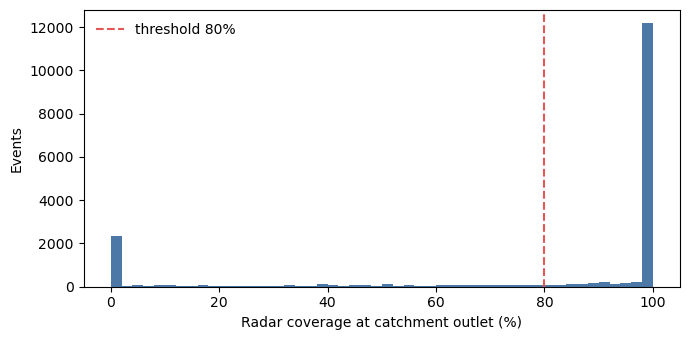

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(ev["radar_coverage_outlet"].dropna(), bins=50, color="#4C78A8")
ax.axvline(RADAR_COVERAGE_THRESHOLD, color="#E45756", ls="--", label=f"threshold {RADAR_COVERAGE_THRESHOLD:g}%")
ax.set_xlabel("Radar coverage at catchment outlet (%)")
ax.set_ylabel("Events")
ax.legend(frameon=False)
plt.tight_layout()

## 9. *(Optional)* Match the closest downstream gage

Skipped entirely when `MATCH_GAGES = False`. Matching never removes events. Filtering on it happens in the last step, and only when `REQUIRE_GAGE = True`.

* **Snap:** each gage is snapped to its nearest flowpath.
* **Candidates:** every flowpath downstream of the storm's flowpath, including the storm's own, is collected. The candidates are the gages on those flowpaths.
* **Pick:** the gage with the smallest straight-line distance to the storm centroid (EPSG:5070) is kept.

In [14]:
if MATCH_GAGES:
    gages = pd.read_csv(GAGES_CSV, dtype={"STAID": str}, low_memory=False)
    require_columns(gages, ["STAID", "LAT_GAGE", "LNG_GAGE"])
    gages["STAID"] = gages["STAID"].astype(str).str.strip().str.zfill(8)
    gages_gdf = gpd.GeoDataFrame(
        gages, geometry=gpd.points_from_xy(gages["LNG_GAGE"], gages["LAT_GAGE"]), crs="EPSG:4326"
    ).to_crs(flowpaths.crs)

    snapped = gpd.sjoin_nearest(gages_gdf, flowpaths[["id", "geometry"]], how="left",
                                distance_col="gage_snap_dist_m") \
                 .rename(columns={"id": "gage_flowpath-id"}) \
                 .drop(columns=["index_right"], errors="ignore") \
                 .drop_duplicates("STAID")
    snapped["gage_cat-id"] = snapped["gage_flowpath-id"].map(flowpath_to_divide)
    snapped = snapped[snapped["gage_flowpath-id"].notna()].reset_index(drop=True)
    print(f"Gages snapped to flowpaths: {len(snapped):,} / {len(gages_gdf):,}")

    g_w = snapped.geometry.to_crs(WORK_CRS)
    gx, gy = g_w.x.to_numpy(), g_w.y.to_numpy()
    gages_on_fp = snapped.groupby("gage_flowpath-id").indices   # flowpath id -> row positions

    downstream_cache = {}
    records = []
    todo = ev[ev["storm_flowpath-id"].notna()]
    for idx, fp in tqdm(todo["storm_flowpath-id"].items(), total=len(todo), desc="Downstream gages"):
        if fp not in graph:
            continue
        if fp not in downstream_cache:
            ds = nx.descendants(graph, fp) | {fp}
            pos = [gages_on_fp[d] for d in ds if d in gages_on_fp]
            downstream_cache[fp] = np.concatenate(pos) if pos else np.array([], dtype=int)
        cand = downstream_cache[fp]
        if cand.size == 0:
            continue
        sx, sy = storm_w[idx].x, storm_w[idx].y
        dist = np.hypot(gx[cand] - sx, gy[cand] - sy)
        best = snapped.iloc[cand[np.argmin(dist)]]
        records.append({
            "cluster_id": ev.at[idx, "cluster_id"],
            "STAID": best["STAID"],
            "DRAIN_SQKM": best.get("DRAIN_SQKM", np.nan),
            "gage_lat": best["LAT_GAGE"],
            "gage_lon": best["LNG_GAGE"],
            "gage_cat-id": best["gage_cat-id"],
            "gage_flowpath-id": best["gage_flowpath-id"],
            "gage_snap_dist_m": best["gage_snap_dist_m"],
            "storm_gage_dist_m": float(dist.min()),
        })
    match = pd.DataFrame(records, columns=["cluster_id", "STAID", "DRAIN_SQKM", "gage_lat", "gage_lon",
                                           "gage_cat-id", "gage_flowpath-id", "gage_snap_dist_m",
                                           "storm_gage_dist_m"])
    match["radar_coverage_gage"] = sample_raster(
        gpd.GeoSeries(gpd.points_from_xy(match["gage_lon"], match["gage_lat"]), crs="EPSG:4326"), RADAR_RASTER)

    ev = ev.drop(columns=[c for c in match.columns if c != "cluster_id" and c in ev.columns])
    ev = ev.merge(match, on="cluster_id", how="left")
    print(f"Events with a downstream gage: {ev['STAID'].notna().sum():,} / {len(todo):,} on a flowpath")
    display(ev.loc[ev["STAID"].notna(), ["cluster_id", "storm_flowpath-id", "STAID", "gage_flowpath-id",
                                         "storm_gage_dist_m", "radar_coverage_outlet", "radar_coverage_gage"]].head())
else:
    print("MATCH_GAGES = False: skipping gage matching.")

MATCH_GAGES = False: skipping gage matching.


## 10. Filter and save

All filters are applied here, in order. The gage requirement comes last and only runs when `REQUIRE_GAGE = True`. The funnel table shows where events drop out.

In [15]:
out = ev.copy()
funnel = [("Merged NOAA events", len(out))]

out = out[out["storm_flowpath-id"].notna()]
funnel.append(("Centroid in a divide with a flowpath", len(out)))
out = out[out["outlet_type"].notna()]
funnel.append(("Catchment outlet located", len(out)))
out = out[out["radar_coverage_outlet"].notna()]
funnel.append(("Outlet has a radar value", len(out)))
if FILTER_BY_RADAR_COVERAGE:
    out = out[out["radar_coverage_outlet"] >= RADAR_COVERAGE_THRESHOLD]
    funnel.append((f"Outlet coverage >= {RADAR_COVERAGE_THRESHOLD:g}%", len(out)))
if MATCH_GAGES and REQUIRE_GAGE:
    out = out[out["STAID"].notna()]
    funnel.append(("Has a downstream gage", len(out)))

out = out.drop(columns=["STATID"], errors="ignore").reset_index(drop=True)
display(pd.DataFrame(funnel, columns=["stage", "events"]))

if OUTPUT_CSV:
    output_path = Path(OUTPUT_CSV)
elif len(YEARS) == 1:
    output_path = Path(f"flashflood_final_events_{YEARS[0]}.csv")
else:
    output_path = Path(f"flashflood_final_events_{min(YEARS)}_{max(YEARS)}.csv")
out.to_csv(output_path, index=False)
print(f"Saved {len(out):,} rows -> {output_path.resolve()}")

,stage,events
0,Merged NOAA events,20128
1,Centroid in a divide with a flowpath,18897
2,Catchment outlet located,18897
3,Outlet has a radar value,18234
4,Outlet coverage >= 80%,13502


Saved 13,502 rows -> C:\Users\keise\NOAA_Materials\flashflood_final_events_2021_2025.csv


### How outlet coverage compares with coverage at the gage

This only runs when gages were matched. It counts how many events pass the threshold at the catchment outlet versus at the gage (the original script's test).

In [16]:
if MATCH_GAGES:
    cmp = ev.dropna(subset=["radar_coverage_outlet", "radar_coverage_gage"])
    display(pd.crosstab(cmp["radar_coverage_outlet"] >= RADAR_COVERAGE_THRESHOLD,
                        cmp["radar_coverage_gage"] >= RADAR_COVERAGE_THRESHOLD,
                        rownames=["outlet passes"], colnames=["gage passes"]))

## 11. Visual check of one event

The map below shows one event with:
* its catchment (divide) and flowpath
* the outlet nexus
* the storm centroid
* the downstream route to the matched gage, when there is one

Set `CHECK_EVENT` to any `cluster_id`. Leave it as `None` to plot the retained event with the most reports.

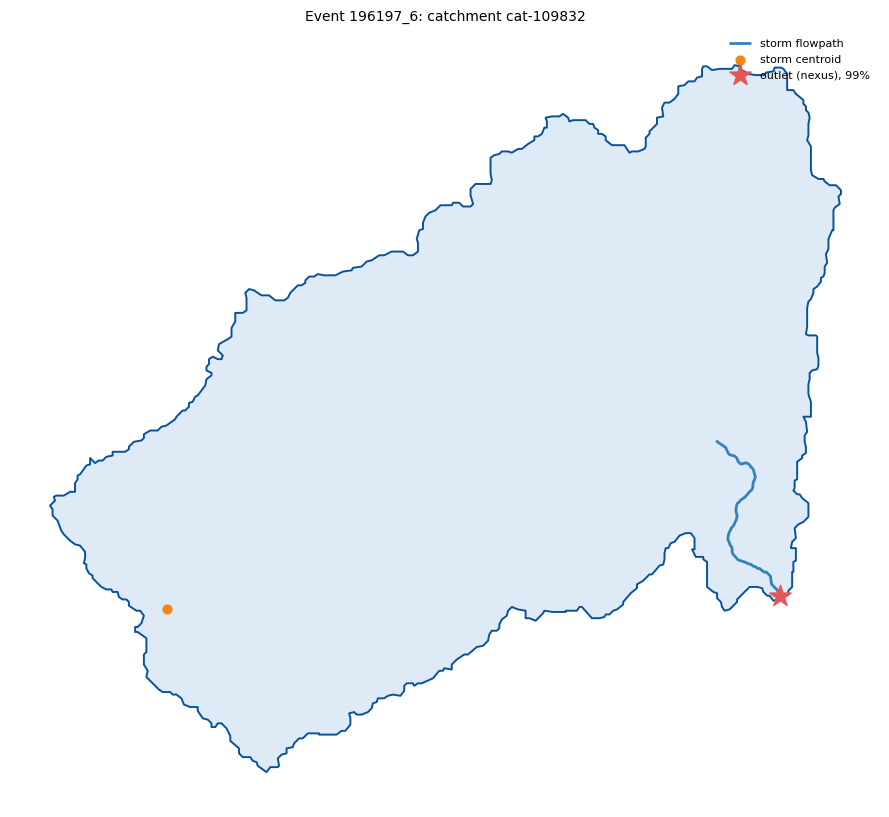

In [23]:
CHECK_EVENT = None   # e.g. "154248_1"

r = ev.set_index("cluster_id").loc[str(CHECK_EVENT)] if CHECK_EVENT else \
    out.sort_values("n_reports", ascending=False).iloc[0]
cid = CHECK_EVENT or r["cluster_id"]
crs = divides.crs
div_geom = divides.drop_duplicates("divide_id").set_index("divide_id").geometry
storm_div = div_geom.get(r["storm_cat-id"])

# Nexus point, and whether it falls outside the storm's divide.
nex_id = r.get("outlet_nexus_id")
nex_pt = None
if nexus is not None and isinstance(nex_id, str):
    m = nexus.loc[nexus["id"] == nex_id]
    if not m.empty:
        nex_pt = m.to_crs(crs).geometry.iloc[0]
nexus_outside = nex_pt is not None and storm_div is not None and not storm_div.buffer(50).contains(nex_pt)

# If it's outside, collect every catchment that connects at that nexus:
#   - all flowpaths that drain into the nexus (the storm's flowpath and the other tributaries)
#   - the flowpath the nexus drains into
#   - any divide the nexus point itself sits in
context_fps, context_divs = [], []
if nexus_outside:
    upstream_fps = network.loc[network["toid"] == nex_id, "id"].dropna().unique().tolist()
    downstream_fps = network.loc[network["id"] == nex_id, "toid"].dropna().unique().tolist()
    context_fps = [f for f in upstream_fps + downstream_fps if f != r["storm_flowpath-id"]]
    context_divs = [flowpath_to_divide[f] for f in context_fps if f in flowpath_to_divide.index]
    context_divs += divides.loc[divides.intersects(nex_pt.buffer(50)), "divide_id"].tolist()
    context_divs = [d for d in dict.fromkeys(context_divs) if d != r["storm_cat-id"]]

# Storm flowpath, plus the route to the matched gage if there is one.
route = [r["storm_flowpath-id"]]
if MATCH_GAGES and isinstance(r.get("gage_flowpath-id"), str) and r["gage_flowpath-id"] in graph:
    try:
        route = [n for n in nx.shortest_path(graph, r["storm_flowpath-id"], r["gage_flowpath-id"])
                 if not str(n).startswith("nex")]
    except nx.NetworkXNoPath:
        pass

fig, ax = plt.subplots(figsize=(9, 9))

if context_divs:
    divides[divides["divide_id"].isin(context_divs)].plot(
        ax=ax, facecolor="#f2f2f2", edgecolor="#9e9e9e", lw=0.8)
    for d in context_divs:
        p = div_geom[d].representative_point()
        ax.annotate(d, (p.x, p.y), fontsize=7, color="#6b6b6b", ha="center")
divides[divides["divide_id"] == r["storm_cat-id"]].plot(ax=ax, facecolor="#deebf7", edgecolor="#08519c", lw=1.4)

if context_fps:
    other = get_flowpaths(context_fps)
    if not other.empty:
        other.plot(ax=ax, color="#9ecae1", lw=1.2, label="connected flowpaths")
fps = get_flowpaths(route)
if not fps.empty:
    fps.plot(ax=ax, color="#3182bd", lw=2.0,
             label="storm flowpath / route to gage" if len(route) > 1 else "storm flowpath")

gpd.GeoSeries([Point(r["centroid_lon"], r["centroid_lat"])], crs="EPSG:4326").to_crs(crs) \
    .plot(ax=ax, color="#F58518", markersize=40, zorder=5, label="storm centroid")
gpd.GeoSeries([Point(r["outlet_lon"], r["outlet_lat"])], crs="EPSG:4326").to_crs(crs) \
    .plot(ax=ax, marker="*", color="#E45756", markersize=260, zorder=6,
          label=f"outlet ({r['outlet_type']}), {r['radar_coverage_outlet']:.0f}%")
if nex_pt is not None and r.get("outlet_type") != "nexus":
    gpd.GeoSeries([nex_pt], crs=crs).plot(ax=ax, marker="D", facecolor="none", edgecolor="#555555",
                                          markersize=60, zorder=6, label=f"nexus {nex_id}")
if MATCH_GAGES and pd.notna(r.get("STAID")):
    gpd.GeoSeries([Point(r["gage_lon"], r["gage_lat"])], crs="EPSG:4326").to_crs(crs) \
        .plot(ax=ax, marker="^", color="#54A24B", markersize=80, zorder=6, label=f"gage {r['STAID']}")

title = f"Event {cid}: catchment {r['storm_cat-id']}"
if nexus_outside:
    title += f"\nnexus {nex_id} is outside the storm catchment; showing {len(context_divs)} connected catchment(s)"
ax.set_title(title, fontsize=10)
ax.legend(loc="best", frameon=False, fontsize=8)
ax.set_axis_off()
plt.tight_layout()